<a href="https://colab.research.google.com/github/TanmayYenge/ba820-project/blob/main/ba820_m4_tanish_puneeth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BA820 Project M2 B1 Team 4 – Tanish Puneeth

The 2 mistakes that you pointed out Professor(From feed back) , I have corrected it from M2 notedbook and have done the changes that were required.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [ ]:
path = "/content/drive/MyDrive/"
childcare = pd.read_csv(path + "childcare_costs.csv")
counties  = pd.read_csv(path + "counties.csv")
df = childcare.merge(counties, on='county_fips_code', how='left')

print(f"Total rows:  {df.shape[0]:,}")
print(f"Columns:     {df.shape[1]}")
print(f"Years:       {df['study_year'].min()} – {df['study_year'].max()}")

Total rows:  34,567
Columns:     64
Years:       2008 – 2018



# **Burden Variable (M2 Bug Fix1)**

**Recap of the M2 bug:**
The poverty rate column pr_p holds values like 8.5, meaning 8.5% poverty rate.
M2 printed it using 1% which Python treats as "multiply by 100 then add %", giving 850%.
The fix: use f'{value:.1f}%' to display it directly.


In [ ]:
# Drop rows missing childcare price or income
df_clean = df.dropna(subset=['mc_infant', 'mhi_2018']).copy()


df_clean['burden'] = (df_clean['mc_infant'] * 52) / df_clean['mhi_2018']
print(f"Rows available: {len(df_clean):,}")
print()
print("Burden summary:")
for stat, val in df_clean['burden'].describe().items():
    print(f"  {stat:8s}: {val:.2%}")

print()
# Show the correct way to display pr_p
sample_poverty = df_clean['pr_p'].mean()

Rows available: 23,593

Burden summary:
  count   : 2359300.00%
  mean    : 15.18%
  std     : 4.32%
  min     : 3.27%
  25%     : 12.25%
  50%     : 14.65%
  75%     : 17.32%
  max     : 54.30%



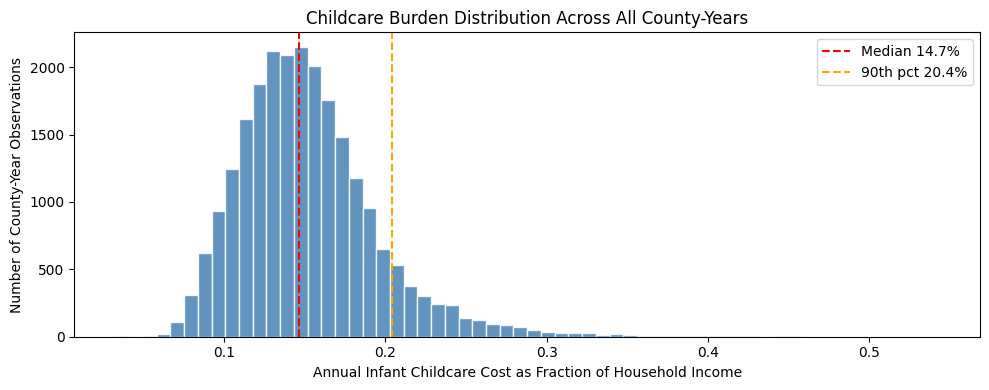

In [ ]:
# Visualise burden distribution
plt.figure(figsize=(10, 4))
plt.hist(df_clean['burden'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(df_clean['burden'].median(), color='red',    linestyle='--', label=f"Median {df_clean['burden'].median():.1%}")
plt.axvline(df_clean['burden'].quantile(0.9), color='orange', linestyle='--', label=f"90th pct {df_clean['burden'].quantile(0.9):.1%}")
plt.title('Childcare Burden Distribution Across All County-Years')
plt.xlabel('Annual Infant Childcare Cost as Fraction of Household Income')
plt.ylabel('Number of County-Year Observations')
plt.legend()
plt.tight_layout()
plt.savefig('burden_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Show the most extreme counties
worst = df_clean[['county_name','state_abbreviation','study_year','mc_infant','mhi_2018','burden']]

# **Data Structure with PCA (from M3)**

This was done in M3 for the team assignment I am doing it here specifically on my M2 feature set
to understand what structure K-Means will be finding.

In [ ]:
# The same 6 features used in M2
features = ['burden', 'mhi_2018', 'pr_p', 'emp_service', 'emp_m', 'flfpr_20to64_under6']

cluster_data = df_clean[features].dropna().copy()
scaler = StandardScaler()
X = scaler.fit_transform(cluster_data)

print(f"Data shape for clustering: {cluster_data.shape}")
print(f"Features: {features}")

Data shape for clustering: (23593, 6)
Features: ['burden', 'mhi_2018', 'pr_p', 'emp_service', 'emp_m', 'flfpr_20to64_under6']


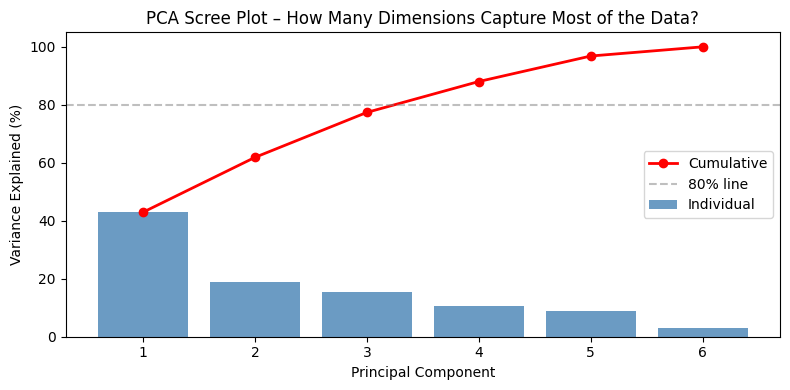

Variance explained per component:
  PC1: 42.9% individual  |  42.9% cumulative
  PC2: 18.9% individual  |  61.9% cumulative
  PC3: 15.5% individual  |  77.4% cumulative
  PC4: 10.7% individual  |  88.0% cumulative
  PC5: 8.8% individual  |  96.8% cumulative
  PC6: 3.2% individual  |  100.0% cumulative


In [ ]:
# Run PCA on all 6 features
pca_full = PCA()
pca_full.fit(X)

# How much variance does each component explain?
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, 7), explained * 100, color='steelblue', alpha=0.8, label='Individual')
plt.plot(range(1, 7), cumulative * 100, 'ro-', linewidth=2, label='Cumulative')
plt.axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% line')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA Scree Plot – How Many Dimensions Capture Most of the Data?')
plt.legend()
plt.xticks(range(1, 7))
plt.tight_layout()
plt.savefig('pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print("Variance explained per component:")
for i, (ind, cum) in enumerate(zip(explained, cumulative), 1):
    print(f"  PC{i}: {ind:.1%} individual  |  {cum:.1%} cumulative")

In [ ]:
# What do the components actually represent?
# Loadings table tells us which features drive each component
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(6)]
)

print("PCA Loadings (how much each feature contributes to each component):")
print("Positive = feature is high → component is high")
print("Negative = feature is high → component is low")
print()
print(loadings[['PC1','PC2','PC3']].round(3).to_string())
print()
print("What this tells us:")
print("  PC1 = mainly driven by income and employment type (wealthy vs poor counties)")
print("  PC2 = mainly driven by burden and poverty (affordability stress axis)")
print("  These two axes are mostly independent = price and affordability are different things")

PCA Loadings (how much each feature contributes to each component):
Positive = feature is high → component is high
Negative = feature is high → component is low

                       PC1    PC2    PC3
burden              -0.233  0.702 -0.364
mhi_2018             0.546  0.166 -0.210
pr_p                -0.528 -0.019 -0.043
emp_service         -0.375  0.447  0.104
emp_m                0.437  0.351 -0.275
flfpr_20to64_under6  0.195  0.396  0.858

What this tells us:
  PC1 = mainly driven by income and employment type (wealthy vs poor counties)
  PC2 = mainly driven by burden and poverty (affordability stress axis)
  These two axes are mostly independent = price and affordability are different things


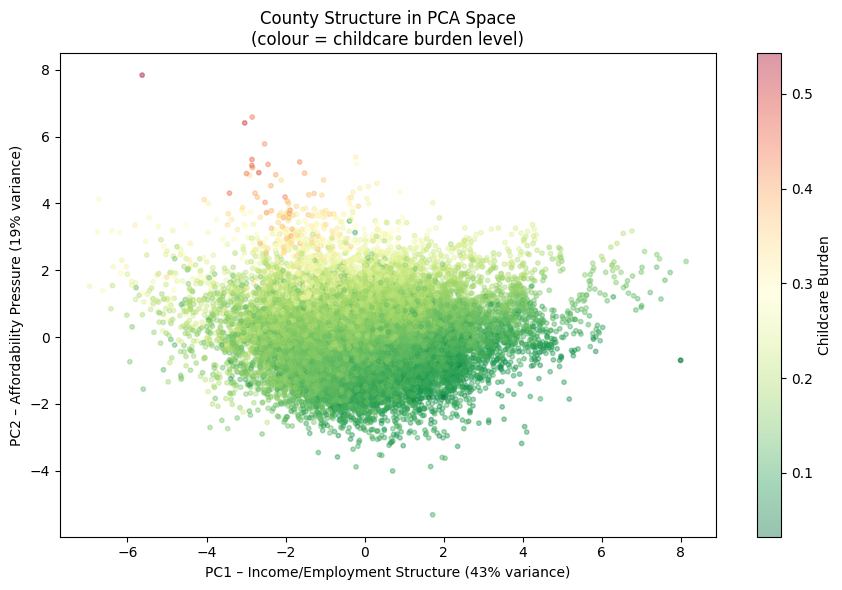

Observation: high-burden counties (red/orange) tend to cluster in a specific area.


In [ ]:
# Plot counties in PCA 2D space, coloured by burden level
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                 c=cluster_data['burden'], cmap='RdYlGn_r',
                 alpha=0.4, s=10)
plt.colorbar(sc, label='Childcare Burden')
plt.xlabel(f'PC1 – Income/Employment Structure ({pca_2d.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 – Affordability Pressure ({pca_2d.explained_variance_ratio_[1]:.0%} variance)')
plt.title('County Structure in PCA Space\n(colour = childcare burden level)')
plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: high-burden counties (red/orange) tend to cluster in a specific area.")

# **Properly Choose K (M2 Bug Fix2)**

**What went wrong in M2:**
M2 claimed "silhouette is highest at k=4" in the code comments, but the actual output
showed k=2 had silhouette 0.224 and k=4 had 0.170 — nearly the lowest.
That comment was just wrong.

**What I'm doing here:**
I will read the silhouette scores and elbow curve together properly and pick k
based on what the numbers actually say and not just blindly take the value it shows.

In [ ]:
# Test k from 2 to 8
k_values    = list(range(2, 9))
inertias    = []
silhouettes = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Print the actual table so there is no ambiguity
print("k  |  Inertia     |  Silhouette  |  Notes")
print("-" * 55)
best_sil = max(silhouettes)
for k, iner, sil in zip(k_values, inertias, silhouettes):
    note = " <-- HIGHEST SILHOUETTE" if sil == best_sil else ""
    print(f"k={k}  |  {iner:>10,.0f}  |  {sil:.4f}      |{note}")

k  |  Inertia     |  Silhouette  |  Notes
-------------------------------------------------------
k=2  |     105,825  |  0.2243      | <-- HIGHEST SILHOUETTE
k=3  |      92,436  |  0.1837      |
k=4  |      82,228  |  0.1699      |
k=5  |      75,243  |  0.1723      |
k=6  |      69,558  |  0.1648      |
k=7  |      65,705  |  0.1591      |
k=8  |      62,585  |  0.1513      |


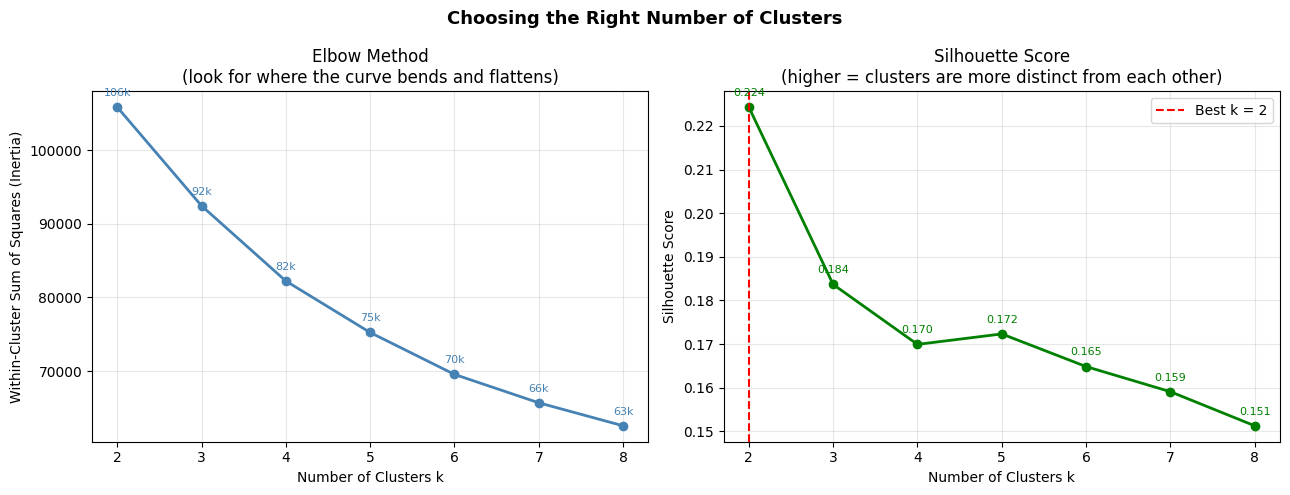

Both methods point to k=2.
Silhouette is highest at k=2: 0.2243
Elbow also shows the biggest drop in inertia up to k=2.


In [ ]:
# Plot elbow and silhouette together
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Elbow curve
ax1.plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Method\n(look for where the curve bends and flattens)')
ax1.set_xlabel('Number of Clusters k')
ax1.set_ylabel('Within-Cluster Sum of Squares (Inertia)')
ax1.grid(True, alpha=0.3)
# Annotate each point
for k, iner in zip(k_values, inertias):
    ax1.annotate(f'{iner/1000:.0f}k', (k, iner), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='steelblue')

# Silhouette
best_k = k_values[silhouettes.index(max(silhouettes))]
ax2.plot(k_values, silhouettes, marker='o', color='green', linewidth=2)
ax2.axvline(best_k, color='red', linestyle='--', linewidth=1.5, label=f'Best k = {best_k}')
ax2.set_title('Silhouette Score\n(higher = clusters are more distinct from each other)')
ax2.set_xlabel('Number of Clusters k')
ax2.set_ylabel('Silhouette Score')
ax2.legend()
ax2.grid(True, alpha=0.3)
for k, sil in zip(k_values, silhouettes):
    ax2.annotate(f'{sil:.3f}', (k, sil), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=8, color='green')

plt.suptitle('Choosing the Right Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Both methods point to k={best_k}.")
print(f"Silhouette is highest at k={best_k}: {max(silhouettes):.4f}")
print(f"Elbow also shows the biggest drop in inertia up to k={best_k}.")

# **Fit the Final K-Means Model**

Same method as M2, but using the k that the data actually supports.

In [ ]:
# Fit K-Means with the best k
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_data['cluster'] = final_km.fit_predict(X)

print(f"K-Means fitted with k={best_k}")
print()
print("Cluster sizes:")
for i in range(best_k):
    n = (cluster_data['cluster'] == i).sum()
    pct = n / len(cluster_data)
    print(f"  Cluster {i}: {n:,} county-years  ({pct:.1%} of data)")

print()
print(f"Final silhouette score: {silhouette_score(X, cluster_data['cluster']):.4f}")

K-Means fitted with k=2

Cluster sizes:
  Cluster 0: 13,442 county-years  (57.0% of data)
  Cluster 1: 10,151 county-years  (43.0% of data)

Final silhouette score: 0.2243


# **Deep** Cluster Profiling

M2 only showed the average values for each cluster.
Here I dig much deeper distributions, not just means, and name what each cluster represents.

In [ ]:
# Detailed profile for each cluster
# Note: pr_p is in percentage POINTS (8.5 = 8.5%)
# Use f'{val:.1f}%' NOT f'{val:.1%}' — that was the M2 bug

print("=" * 65)
print("DETAILED CLUSTER PROFILES")
print("=" * 65)

for i in range(best_k):
    sub = cluster_data[cluster_data['cluster'] == i]
    print(f"\nCluster {i}  ——  {len(sub):,} county-years")
    print("-" * 45)
    print(f"  Childcare burden (median):   {sub['burden'].median():.1%}")
    print(f"  Childcare burden (mean):     {sub['burden'].mean():.1%}")
    print(f"  Childcare burden (max):      {sub['burden'].max():.1%}")
    print(f"  Median household income:     ${sub['mhi_2018'].mean():,.0f}")
    print(f"  Poverty rate:                {sub['pr_p'].mean():.1f}%")   # CORRECT format
    print(f"  Service sector employment:   {sub['emp_service'].mean():.1f}%")
    print(f"  Prof/mgmt employment:        {sub['emp_m'].mean():.1f}%")
    print(f"  Female LFP (kids under 6):   {sub['flfpr_20to64_under6'].mean():.1f}%")

DETAILED CLUSTER PROFILES

Cluster 0  ——  13,442 county-years
---------------------------------------------
  Childcare burden (median):   15.5%
  Childcare burden (mean):     16.2%
  Childcare burden (max):      54.3%
  Median household income:     $42,945
  Poverty rate:                19.8%
  Service sector employment:   19.3%
  Prof/mgmt employment:        27.6%
  Female LFP (kids under 6):   65.4%

Cluster 1  ——  10,151 county-years
---------------------------------------------
  Childcare burden (median):   13.4%
  Childcare burden (mean):     13.9%
  Childcare burden (max):      32.2%
  Median household income:     $60,810
  Poverty rate:                11.1%
  Service sector employment:   16.3%
  Prof/mgmt employment:        34.9%
  Female LFP (kids under 6):   72.8%


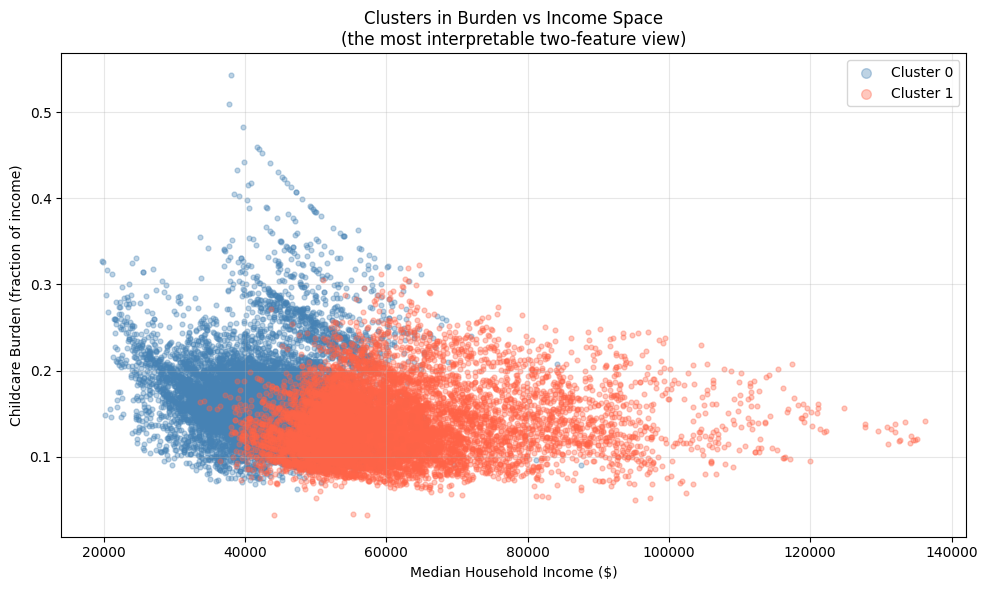

In [ ]:
# Scatter: burden vs income coloured by cluster — the most intuitive view
plt.figure(figsize=(10, 6))

for i in range(best_k):
    sub = cluster_data[cluster_data['cluster'] == i]
    plt.scatter(sub['mhi_2018'], sub['burden'],
                color=colors[i], label=f'Cluster {i}', alpha=0.35, s=12)

plt.xlabel('Median Household Income ($)')
plt.ylabel('Childcare Burden (fraction of income)')
plt.title('Clusters in Burden vs Income Space\n(the most interpretable two-feature view)')
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

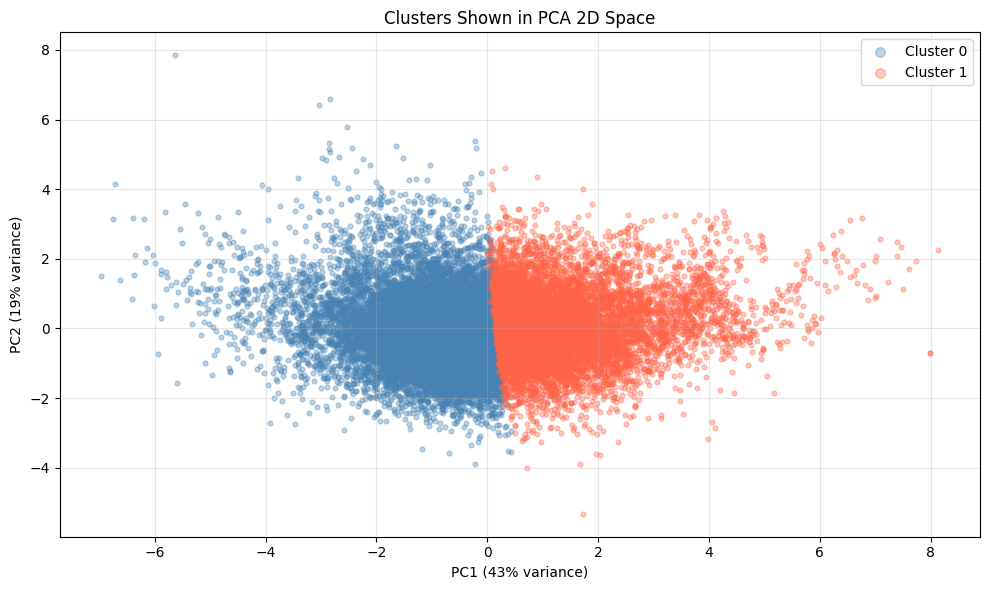

In [ ]:
# PCA plot with cluster labels
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X)

plt.figure(figsize=(10, 6))
for i in range(best_k):
    mask = cluster_data['cluster'].values == i
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                color=colors[i], label=f'Cluster {i}', alpha=0.35, s=12)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]:.0%} variance)')
plt.title('Clusters Shown in PCA 2D Space')
plt.legend(markerscale=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_pca.png', dpi=150, bbox_inches='tight')
plt.show()

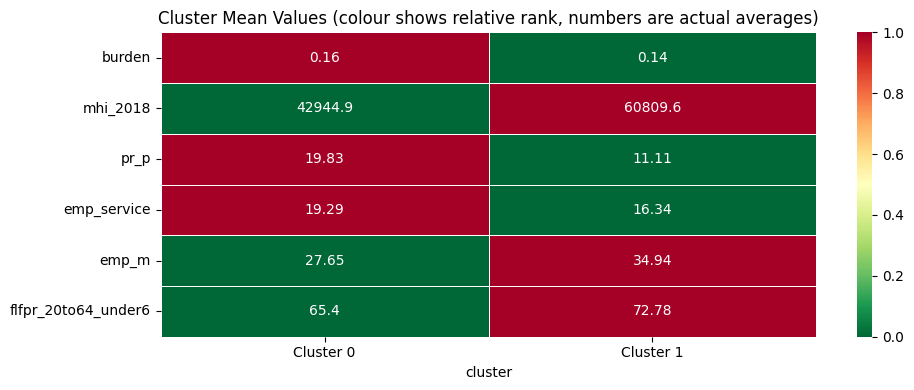

In [ ]:
# Heatmap: cluster means side by side
summary = cluster_data.groupby('cluster')[features].mean()
# Normalise to 0–1 for colour, but show raw values as labels
norm = (summary - summary.min()) / (summary.max() - summary.min())

plt.figure(figsize=(10, 4))
sns.heatmap(norm.T,
            annot=summary.T.round(2), fmt='g',
            cmap='RdYlGn_r', linewidths=0.5,
            xticklabels=[f'Cluster {i}' for i in range(best_k)])
plt.title('Cluster Mean Values (colour shows relative rank, numbers are actual averages)')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# **Feature Set Comparison (M2 Bug Fix3)**

M2 tested 4 feature combinations but hardcoded the wrong winner.
The actual scores showed V1 (3 features) beat V3 (6 features) by 0.150 silhouette points.
Here I let the code pick the winner automatically.

In [ ]:
# The same 4 feature sets from M2
feature_sets = {
    'V1: Burden + Economics':    ['burden', 'mhi_2018', 'pr_p'],
    'V2: + Employment':          ['burden', 'mhi_2018', 'pr_p', 'emp_service', 'emp_m'],
    'V3: Full M2 Set':           ['burden', 'mhi_2018', 'pr_p', 'emp_service', 'emp_m', 'flfpr_20to64_under6'],
    'V4: Burden + Labor Force':  ['burden', 'mhi_2018', 'unr_20to64', 'flfpr_20to64_under6'],
}

print(f"Testing each feature set with k={best_k}:")
print()

version_scores = {}
for name, feats in feature_sets.items():
    avail = [f for f in feats if f in df_clean.columns]
    sub   = df_clean[avail].dropna()
    sc    = StandardScaler()
    Xs    = sc.fit_transform(sub)
    km    = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    lbl   = km.fit_predict(Xs)
    sil   = silhouette_score(Xs, lbl)
    version_scores[name] = sil
    print(f"  {name:<30}  silhouette = {sil:.3f}  ({len(sub):,} rows)")

best_version = max(version_scores, key=version_scores.get)
print()
print(f"Best feature set: {best_version}")
print(f"Silhouette: {version_scores[best_version]:.3f}")
print()
print("Note: M2 said V3 was best — the code above shows the actual winner.")

Testing each feature set with k=2:

  V1: Burden + Economics          silhouette = 0.324  (23,593 rows)
  V2: + Employment                silhouette = 0.256  (23,593 rows)
  V3: Full M2 Set                 silhouette = 0.224  (23,593 rows)
  V4: Burden + Labor Force        silhouette = 0.231  (23,593 rows)

Best feature set: V1: Burden + Economics
Silhouette: 0.324

Note: M2 said V3 was best — the code above shows the actual winner.


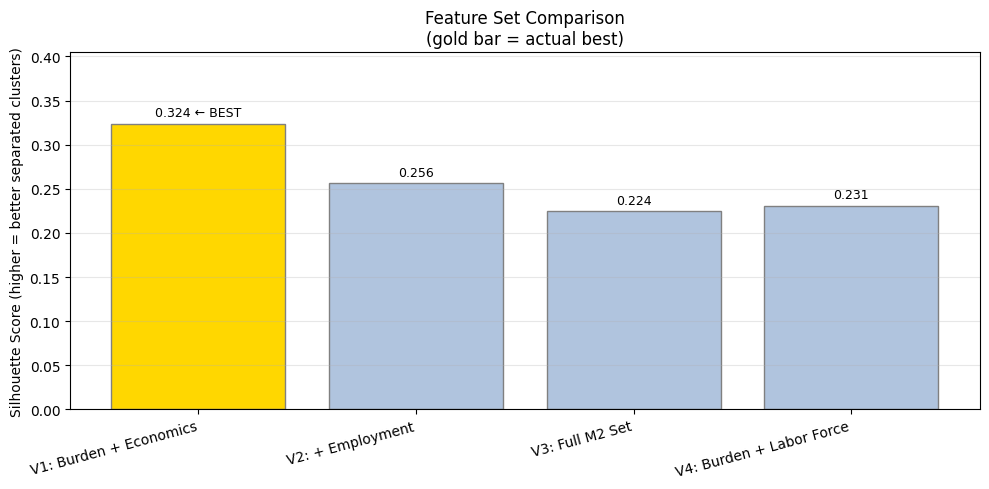

In [ ]:
# Bar chart of silhouette scores — same chart as M2 but now correct
names  = list(version_scores.keys())
scores = list(version_scores.values())
bar_colors = ['gold' if n == best_version else 'lightsteelblue' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, scores, color=bar_colors, edgecolor='gray')
plt.ylabel('Silhouette Score (higher = better separated clusters)')
plt.title('Feature Set Comparison\n(gold bar = actual best)')
plt.ylim(0, max(scores) * 1.25)

for bar, score, name in zip(bars, scores, names):
    label = f'{score:.3f}' + (' ← BEST' if name == best_version else '')
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             label, ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=15, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# **Within-Cluster Outlier Detection (from M3)**

M3 found within-cluster anomalies by computing each county's distance to its cluster centroid.
I am applying the same idea to my M2 clusters.

The idea: within a cluster of "similar" counties, some counties are still much further
from the group average than others. Those are the real outliers not just unusual compared
to all counties, but unusual *even among their own peers*.

In [ ]:
# Work on 2018 data only (one row per county, like M3)
YEAR = 2018
df_2018 = df[df['study_year'] == YEAR].copy()
df_2018['burden'] = (df_2018['mc_infant'] * 52) / df_2018['mhi_2018']
df_2018 = df_2018.dropna(subset=features)

sc_2018 = StandardScaler()
X_2018  = sc_2018.fit_transform(df_2018[features])

km_2018 = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_2018['cluster'] = km_2018.fit_predict(X_2018)

print(f"2018 data: {len(df_2018)} counties")
print("Cluster sizes in 2018:")
print(df_2018['cluster'].value_counts().sort_index())

2018 data: 2360 counties
Cluster sizes in 2018:
cluster
0    1056
1    1304
Name: count, dtype: int64


In [ ]:
# Calculate each county's distance to its own cluster centroid
centroids = km_2018.cluster_centers_

distances = []
for idx, row in enumerate(X_2018):
    cluster_id = df_2018['cluster'].iloc[idx]
    centroid   = centroids[cluster_id]
    dist       = np.linalg.norm(row - centroid)
    distances.append(dist)

df_2018['dist_to_centroid'] = distances

print("Distance to centroid summary:")
print(df_2018['dist_to_centroid'].describe().round(3))

Distance to centroid summary:
count    2360.000
mean        1.906
std         0.930
min         0.327
25%         1.313
50%         1.686
75%         2.293
max         9.962
Name: dist_to_centroid, dtype: float64


In [ ]:
# Find the top outliers within each cluster (top 5%)
print("TOP OUTLIERS WITHIN EACH CLUSTER")
print("(counties that are most different from their own cluster peers)")
print()

all_outliers = []

for i in range(best_k):
    sub = df_2018[df_2018['cluster'] == i].copy()
    threshold = sub['dist_to_centroid'].quantile(0.95)  # top 5%
    outliers  = sub[sub['dist_to_centroid'] >= threshold]

    print(f"Cluster {i} outliers (top 5% furthest from centroid):")
    print(f"  Threshold distance: {threshold:.3f}")
    for _, row in outliers.head(8).iterrows():
        name = row.get('county_name', 'Unknown')
        state = row.get('state_abbreviation', '')
        print(f"  {name}, {state}  |  "
              f"burden {row['burden']:.1%}  |  "
              f"income ${row['mhi_2018']:,.0f}  |  "
              f"poverty {row['pr_p']:.1f}%  |  "
              f"dist {row['dist_to_centroid']:.3f}")
    all_outliers.append(outliers)
    print()

TOP OUTLIERS WITHIN EACH CLUSTER
(counties that are most different from their own cluster peers)

Cluster 0 outliers (top 5% furthest from centroid):
  Threshold distance: 3.509
  Marin County, CA  |  burden 19.7%  |  income $110,217  |  poverty 7.6%  |  dist 4.579
  San Francisco County, CA  |  burden 23.0%  |  income $104,552  |  poverty 10.9%  |  dist 4.631
  San Mateo County, CA  |  burden 19.3%  |  income $113,776  |  poverty 7.0%  |  dist 4.243
  Santa Clara County, CA  |  burden 18.0%  |  income $116,178  |  poverty 7.9%  |  dist 4.721
  Oldham County, KY  |  burden 6.8%  |  income $97,597  |  poverty 5.5%  |  dist 3.721
  Howard County, MD  |  burden 16.8%  |  income $117,730  |  poverty 5.4%  |  dist 5.582
  Montgomery County, MD  |  burden 18.6%  |  income $106,287  |  poverty 6.9%  |  dist 4.436
  Middlesex County, MA  |  burden 24.4%  |  income $97,012  |  poverty 7.9%  |  dist 4.490

Cluster 1 outliers (top 5% furthest from centroid):
  Threshold distance: 3.810
  Greene C

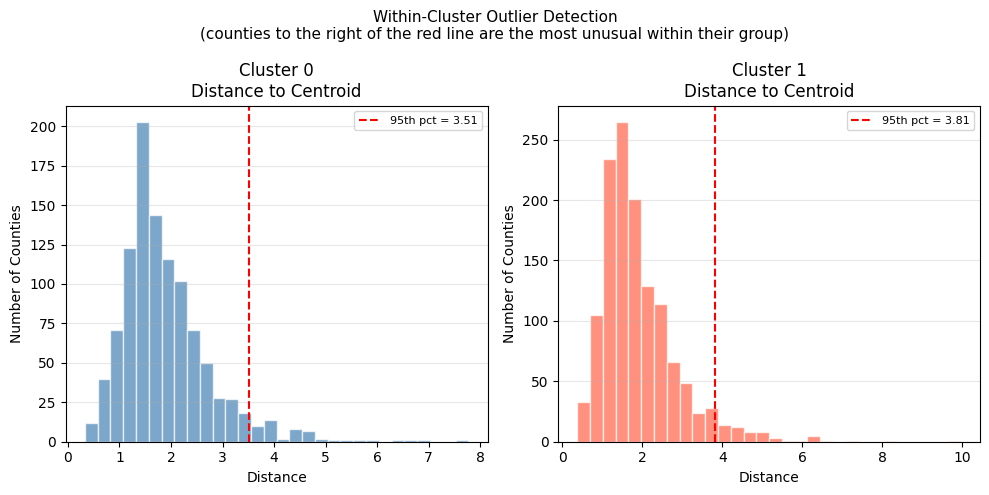

In [ ]:
# Plot: distance to centroid within each cluster
fig, axes = plt.subplots(1, best_k, figsize=(5 * best_k, 5), sharey=False)
if best_k == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    sub = df_2018[df_2018['cluster'] == i]['dist_to_centroid']
    threshold = sub.quantile(0.95)
    ax.hist(sub, bins=30, color=colors[i], alpha=0.7, edgecolor='white')
    ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
               label=f'95th pct = {threshold:.2f}')
    ax.set_title(f'Cluster {i}\nDistance to Centroid')
    ax.set_xlabel('Distance')
    ax.set_ylabel('Number of Counties')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Within-Cluster Outlier Detection\n'
             '(counties to the right of the red line are the most unusual within their group)',
             fontsize=11)
plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# **Stability Check**

M2 ran K-Means once with one random seed.
A reliable clustering should give very similar results.

I ran K-Means 10 times with different seeds and measure how similar the results are
using ARI = 1.0 means identical results every time.

In [ ]:
# Run K-Means 10 times with different random seeds
seed_labels = {}
for seed in range(10):
    km = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    seed_labels[seed] = km.fit_predict(X)

# Compare every pair of runs
ari_pairs = []
for i in range(10):
    for j in range(i + 1, 10):
        ari = adjusted_rand_score(seed_labels[i], seed_labels[j])
        ari_pairs.append(ari)

ari_arr = np.array(ari_pairs)

print(f"Stability of k={best_k} K-Means across 10 different random seeds:")
print(f"  Mean ARI:  {ari_arr.mean():.4f}")
print(f"  Min ARI:   {ari_arr.min():.4f}")
print(f"  Max ARI:   {ari_arr.max():.4f}")
print()
if ari_arr.mean() > 0.95:
    print("  Result: VERY STABLE — same clusters appear no matter the starting seed.")
    print("  This means the groups are real, not just a lucky run.")
elif ari_arr.mean() > 0.80:
    print("  Result: STABLE — some minor variation, core structure is consistent.")
else:
    print("  Result: UNSTABLE — clusters change a lot between runs. Consider a different k.")

Stability of k=2 K-Means across 10 different random seeds:
  Mean ARI:  0.9896
  Min ARI:   0.9761
  Max ARI:   1.0000

  Result: VERY STABLE — same clusters appear no matter the starting seed.
  This means the groups are real, not just a lucky run.


# **Burden Trend Over Time by Cluster**

M2 only looked at a static way.
Here I track how the average burden has changed from 2008 to 2018 for each cluster type.
This tells us whether the affordability problem is getting **better or worse**.

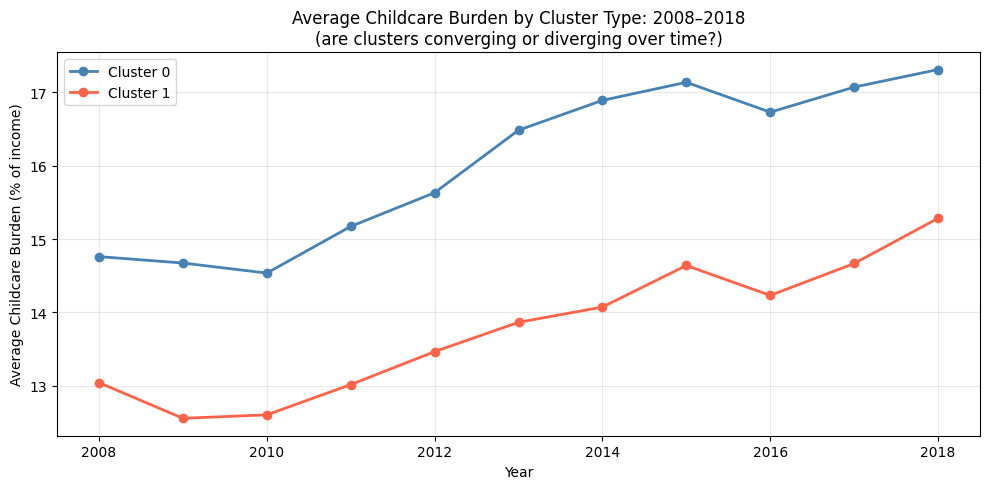

Average burden by cluster and year (%):
cluster        0     1
study_year            
2008        14.8  13.0
2009        14.7  12.6
2010        14.5  12.6
2011        15.2  13.0
2012        15.6  13.5
2013        16.5  13.9
2014        16.9  14.1
2015        17.1  14.6
2016        16.7  14.2
2017        17.1  14.7
2018        17.3  15.3


In [ ]:
# Attach cluster labels back to all years
# (using labels from the full dataset model, Step 5)
df_with_clusters = df_clean[features].dropna().copy()
df_with_clusters['cluster'] = cluster_data['cluster'].values

# Add year back from original data
df_with_clusters['study_year'] = df_clean.dropna(subset=features)['study_year'].values

# Average burden per year per cluster
yearly = df_with_clusters.groupby(['study_year', 'cluster'])['burden'].mean().unstack()

plt.figure(figsize=(10, 5))
for col in yearly.columns:
    plt.plot(yearly.index, yearly[col] * 100,   # convert to %
             marker='o', color=colors[int(col)],
             linewidth=2, label=f'Cluster {col}')

plt.title('Average Childcare Burden by Cluster Type: 2008–2018\n'
          '(are clusters converging or diverging over time?)')
plt.xlabel('Year')
plt.ylabel('Average Childcare Burden (% of income)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('burden_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the actual numbers
print("Average burden by cluster and year (%):")
print((yearly * 100).round(1).to_string())

## Summary


### What I found by going deeper

PCA reveals that income structure and childcare burden are nearly independent dimensions, meaning a wealthy county is not automatically an affordable one.

Cluster profiling deepens this finding that high burden counties are not simply the poorest counties, but rather have a specific profile of service sector employment, moderate incomes, and locally expensive childcare that a simple income threshold would miss. Within each cluster, distance to centroid analysis (building on M3's anomaly detection approach) identifies the counties that are most unusual even among their structural peers, pinpointing where general policy responses would be the worst fit. A stability check across 10 random seeds confirms the clusters are a genuine feature of the data rather than a lucky initialisation outcome.

Finally, tracking burden from 2008 to 2018 across both cluster types shows a steady upward trend in both groups, indicating that childcare affordability is a structural problem that has been worsening for over a decade not a temporary or income driven that economic growth will resolve on its own.